In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Seeds para reprodutibilidade
np.random.seed(1312)

# Paths
RAW_DATA_PATH = Path("../data/raw/telco_churn.csv")

# Estilo dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Imports OK")

Imports OK


In [2]:
df = pd.read_csv(RAW_DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
df.head()

Shape: (7043, 21)
Colunas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("=== Tipos de dados ===")
print(df.dtypes)

print("\n=== Missing values ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== Valores únicos por coluna ===")
print(df.nunique().sort_values())

# corrigir total charges

=== Tipos de dados ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Missing values ===
Series([], dtype: int64)

=== Valores únicos por coluna ===
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection

In [ ]:
# TotalCharges veio como object — converter para numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Verificar quantos NaN foram gerados
print(f"NaN em TotalCharges após conversão: {df['TotalCharges'].isnull().sum()}")

# Inspecionar os registros problemáticos
print(df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]])

# as linhas com NAN são de clientes novos que ainda não geraram cobrança total

NaN em TotalCharges após conversão: 11
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


=== Distribuição do Churn ===
       count    pct
Churn              
No      5174  73.46
Yes     1869  26.54


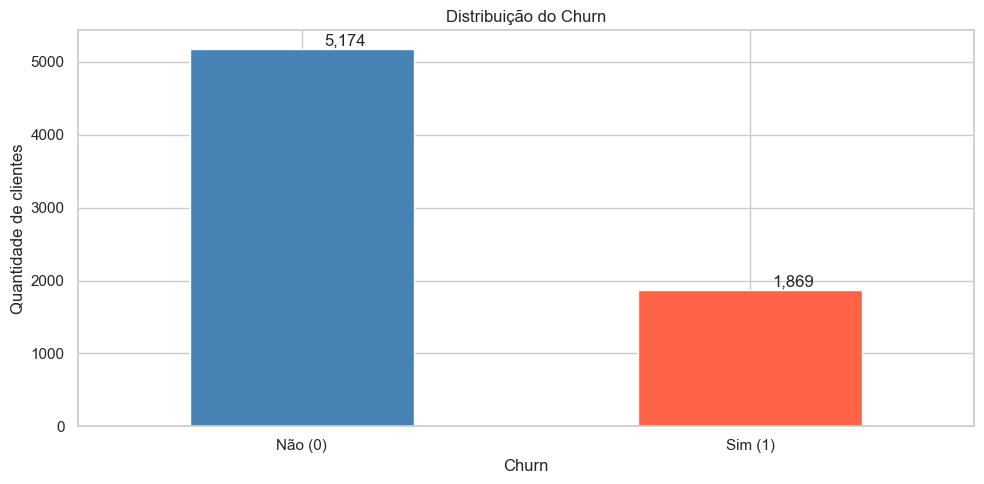

In [5]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("=== Distribuição do Churn ===")
print(pd.DataFrame({"count": churn_counts, "pct": churn_pct.round(2)}))

fig, ax = plt.subplots()
churn_counts.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="white")
ax.set_title("Distribuição do Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Quantidade de clientes")
ax.set_xticklabels(["Não (0)", "Sim (1)"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + 0.3, p.get_height() + 50))
plt.tight_layout()
plt.show()

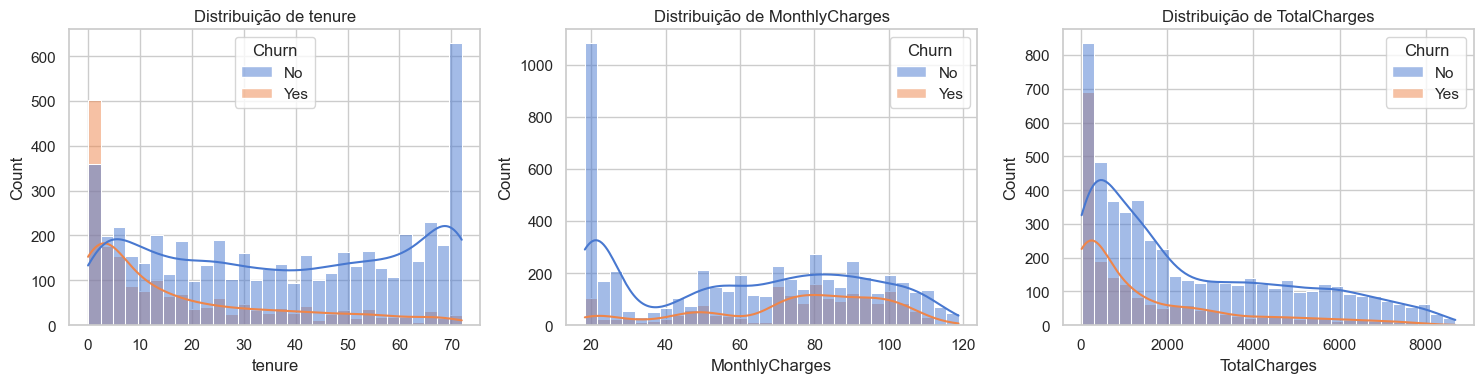


=== Estatísticas descritivas ===
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7032.00
mean     32.37           64.76       2283.30
std      24.56           30.09       2266.77
min       0.00           18.25         18.80
25%       9.00           35.50        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.85       3794.74
max      72.00          118.75       8684.80


In [ ]:
# Distribuição das variáveis numericas por churn

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax, bins=30)
    ax.set_title(f"Distribuição de {col}")
plt.tight_layout()
plt.show()

print("\n=== Estatísticas descritivas ===")
print(df[num_cols].describe().round(2))

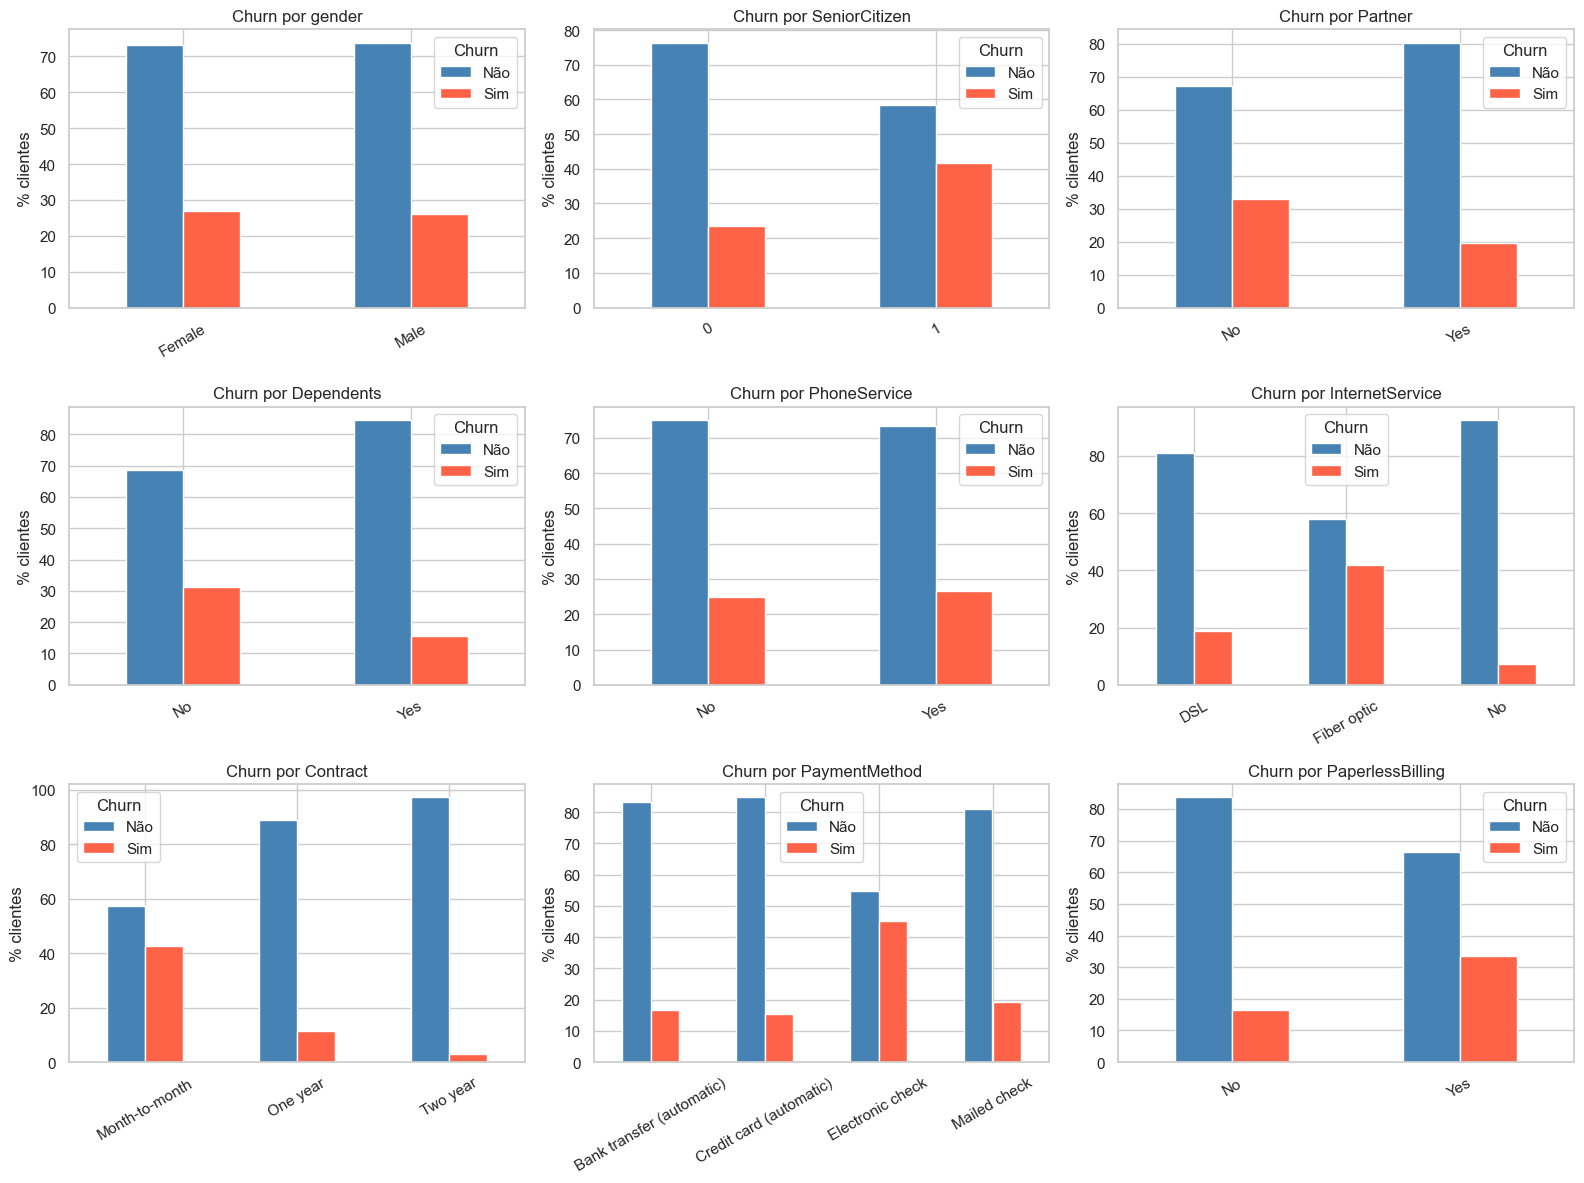

In [ ]:
# Distribuição das variáveis categoricas por churn

cat_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "InternetService", "Contract",
    "PaymentMethod", "PaperlessBilling"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    ct.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="white")
    ax.set_title(f"Churn por {col}")
    ax.set_xlabel("")
    ax.set_ylabel("% clientes")
    ax.legend(["Não", "Sim"], title="Churn")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

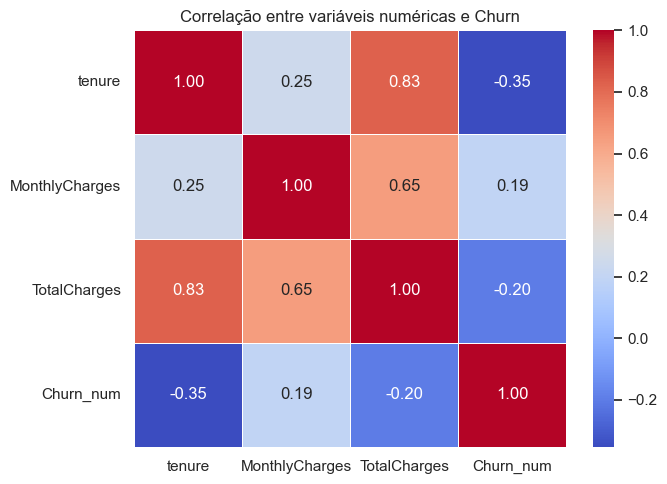

In [8]:
# Encode do target para correlação
df_corr = df.copy()
df_corr["Churn_num"] = (df_corr["Churn"] == "Yes").astype(int)

corr = df_corr[num_cols + ["Churn_num"]].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, linewidths=0.5)
ax.set_title("Correlação entre variáveis numéricas e Churn")
plt.tight_layout()
plt.show()

In [9]:
print("=" * 50)
print("DATA READINESS REPORT")
print("=" * 50)
print(f"Total de registros:        {df.shape[0]:,}")
print(f"Total de features:         {df.shape[1] - 1}")
print(f"Registros com churn=Yes:   {(df['Churn']=='Yes').sum():,} ({(df['Churn']=='Yes').mean()*100:.1f}%)")
print(f"Registros com churn=No:    {(df['Churn']=='No').sum():,} ({(df['Churn']=='No').mean()*100:.1f}%)")
print(f"Missing values totais:     {df.isnull().sum().sum()}")
print(f"Colunas numéricas:         {df.select_dtypes(include='number').shape[1]}")
print(f"Colunas categóricas:       {df.select_dtypes(include='object').shape[1]}")
print(f"Duplicatas:                {df.duplicated().sum()}")
print("=" * 50)
print("CONCLUSÃO: Dataset apto para modelagem com tratamentos mínimos:")
print("  - Converter TotalCharges para numérico")
print("  - Remover customerID (identificador sem valor preditivo)")
print("  - Encodar variáveis categóricas")
print("  - Tratar ~11 registros com TotalCharges nulo")
print("=" * 50)

DATA READINESS REPORT
Total de registros:        7,043
Total de features:         20
Registros com churn=Yes:   1,869 (26.5%)
Registros com churn=No:    5,174 (73.5%)
Missing values totais:     11
Colunas numéricas:         4
Colunas categóricas:       17
Duplicatas:                0
CONCLUSÃO: Dataset apto para modelagem com tratamentos mínimos:
  - Converter TotalCharges para numérico
  - Remover customerID (identificador sem valor preditivo)
  - Encodar variáveis categóricas
  - Tratar ~11 registros com TotalCharges nulo
